In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier, 
    StackingClassifier
)
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.inspection import permutation_importance

In [11]:
# Фиксация random_state для воспроизводимости
RANDOM_STATE = 42

# Пути к файлам
DATASET_PATH = 'S06-hw-dataset-02.csv'
ARTIFACTS_DIR = Path('artifacts')
FIGURES_DIR = ARTIFACTS_DIR / 'figures'


In [3]:
df = pd.read_csv(DATASET_PATH)

# Первичный анализ
print("Первые 5 строк данных:")
display(df.head())

print("\nИнформация о датасете:")
df.info()

print("\nБазовые статистики:")
display(df.describe())

# Анализ распределения таргета
print("\nРаспределение таргета:")
target_distribution = df['target'].value_counts(normalize=True)
print(target_distribution)

# Проверка пропусков
print("\nПроверка пропусков:")
print(df.isnull().sum().sum())

# Подготовка данных
X = df.drop(columns=['id', 'target'])
y = df['target']

print(f"\nРазмеры данных: X.shape = {X.shape}, y.shape = {y.shape}")

Первые 5 строк данных:


,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
0,1,-0.149235,-2.826966,-0.522901,-4.198449,1.364943,0.815043,-1.195518,-1.932232,2.396353,...,-0.159323,0.448015,0.572745,0.149916,0.878392,-0.679733,1.412751,0.421883,9.217167,1
1,2,-1.966180,-4.877542,0.268367,-9.607791,0.097149,1.347185,-3.872575,-0.395117,1.710068,...,-0.389212,1.383794,0.169876,0.043969,-0.963545,1.006643,-2.488690,9.590124,24.772826,0
2,3,-0.555964,-0.999920,0.209673,-14.119498,-1.808950,-0.006222,-4.651108,0.911944,-0.289037,...,-1.383970,3.044321,-0.182864,1.425649,-8.418598,-4.629754,-0.439798,0.555919,41.800517,0
3,4,-2.049199,-5.600713,-1.664677,-6.263893,-5.224455,0.848351,1.407210,-0.542080,0.119102,...,-2.713080,2.762637,-0.520796,-0.142455,1.668338,2.292810,-10.744916,11.476977,65.315860,0
4,5,-0.220556,4.889479,-2.235840,6.450046,0.774389,-2.382625,2.584816,4.211856,-0.317889,...,-1.302872,2.478862,1.528610,1.098131,3.547087,2.517757,-9.364106,-1.078404,93.017870,0



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       18000 non-null  int64  
 1   f01      18000 non-null  float64
 2   f02      18000 non-null  float64
 3   f03      18000 non-null  float64
 4   f04      18000 non-null  float64
 5   f05      18000 non-null  float64
 6   f06      18000 non-null  float64
 7   f07      18000 non-null  float64
 8   f08      18000 non-null  float64
 9   f09      18000 non-null  float64
 10  f10      18000 non-null  float64
 11  f11      18000 non-null  float64
 12  f12      18000 non-null  float64
 13  f13      18000 non-null  float64
 14  f14      18000 non-null  float64
 15  f15      18000 non-null  float64
 16  f16      18000 non-null  float64
 17  f17      18000 non-null  float64
 18  f18      18000 non-null  float64
 19  f19      18000 non-null  float64
 20  f20      18000 non-null  f

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,...,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,1.800000e+04,18000.000000
mean,9000.500000,-0.418555,0.614251,0.004559,0.059000,0.405086,0.012123,-0.283473,-0.266880,0.255107,...,-0.139825,0.108568,0.007238,0.000904,-0.716862,-0.274520,0.344991,1.517339,2.576221e+01,0.262611
std,5196.296758,2.178005,3.926778,1.000134,5.713672,2.497581,0.987226,2.193891,2.081431,2.225776,...,2.148834,2.234315,0.997861,1.002115,3.913704,2.482890,4.927315,10.630850,5.423748e+01,0.440065
min,1.000000,-10.014698,-15.510323,-4.031762,-23.663256,-12.289308,-3.741536,-9.591425,-8.293319,-13.655742,...,-8.171469,-9.214171,-3.937091,-3.963063,-19.389908,-10.031559,-20.768452,-107.788145,1.895059e-07,0.000000
25%,4500.750000,-1.866134,-2.048192,-0.673127,-3.544964,-1.153000,-0.653090,-1.743214,-1.688121,-1.177480,...,-1.589638,-1.369266,-0.663023,-0.684164,-3.286842,-1.897893,-2.752685,-2.018750,1.226029e+00,0.000000
50%,9000.500000,-0.465100,0.600291,0.003581,0.072826,0.485625,0.018765,-0.251263,-0.302463,0.350739,...,-0.204785,0.158715,0.001912,-0.003157,-0.618472,-0.339901,0.573153,0.318011,6.581865e+00,0.000000
75%,13500.250000,0.966393,3.229850,0.671390,3.689490,2.075739,0.689304,1.195481,1.109589,1.764113,...,1.254595,1.600671,0.677296,0.676558,1.948803,1.314163,3.649794,4.212111,2.576847e+01,1.000000
max,18000.000000,9.589975,15.417329,3.817025,26.815691,10.665184,3.528280,7.794627,8.892834,8.699629,...,9.290667,8.794320,4.341030,3.781380,14.065595,10.639974,20.226291,94.891804,1.103449e+03,1.000000



Распределение таргета:
target
0    0.737389
1    0.262611
Name: proportion, dtype: float64

Проверка пропусков:
0

Размеры данных: X.shape = (18000, 37), y.shape = (18000,)


In [4]:
# Разделение данных на train и test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True)}")

# Пояснение: Фиксация random_state гарантирует воспроизводимость результатов при каждом запуске.
# Стратификация (stratify=y) сохраняет пропорции классов в train и test выборках, что критично для
# корректной оценки модели, особенно при наличии дисбаланса классов.

Train size: (14400, 37), Test size: (3600, 37)
Train target distribution:
target
0    0.737361
1    0.262639
Name: proportion, dtype: float64
Test target distribution:
target
0    0.7375
1    0.2625
Name: proportion, dtype: float64


In [5]:
# Словарь для хранения результатов
results = {}
search_summaries = {}

def evaluate_model(model, X_test, y_test, model_name):
    """Оценка модели на тестовых данных"""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    print(f"[{model_name}] Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {roc_auc:.4f}")
    return {
        "Accuracy": acc,
        "F1": f1,
        "ROC-AUC": roc_auc
    }

# DummyClassifier как baseline
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_train)
results['Dummy'] = evaluate_model(dummy_clf, X_test, y_test, 'Dummy')

# LogisticRegression как baseline
logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])
logreg_pipe.fit(X_train, y_train)
results['LogReg'] = evaluate_model(logreg_pipe, X_test, y_test, 'LogReg')

# Пояснение: DummyClassifier (стратегия most_frequent) всегда предсказывает самый частый класс,
# устанавливая "планку" для осмысленных моделей. LogisticRegression через Pipeline со StandardScaler
# обеспечивает корректное масштабирование признаков и служит сильным линейным baseline.

[Dummy] Accuracy: 0.7375 | F1: 0.0000 | ROC-AUC: 0.5000
[LogReg] Accuracy: 0.8119 | F1: 0.5607 | ROC-AUC: 0.7977


In [6]:
# Настройка кросс-валидации
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# DecisionTreeClassifier с контролем сложности
dt_params = {
    'max_depth': [3, 5, 7, 10],  # Ограничение глубины для контроля сложности
    'min_samples_leaf': [5, 10, 20],  # Минимальное количество образцов в листе
    'min_samples_split': [10, 20, 30],  # Минимальное количество образцов для разделения узла
    'ccp_alpha': [0.0, 0.001, 0.01]  # Параметр для pruning
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_params, 
    cv=cv_strategy, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=0
)
dt_grid.fit(X_train, y_train)

# Сохранение результатов поиска
search_summaries['DecisionTree'] = {
    'best_params': dt_grid.best_params_,
    'best_cv_score': dt_grid.best_score_
}
print(f"\nЛучшие параметры DecisionTree: {dt_grid.best_params_}")
print(f"Лучший CV score (ROC-AUC): {dt_grid.best_score_:.4f}")

# Оценка на тесте
results['DecisionTree'] = evaluate_model(dt_grid.best_estimator_, X_test, y_test, 'DecisionTree')


Лучшие параметры DecisionTree: {'ccp_alpha': 0.0, 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 10}
Лучший CV score (ROC-AUC): 0.8367
[DecisionTree] Accuracy: 0.8336 | F1: 0.6515 | ROC-AUC: 0.8374


In [7]:
# RandomForestClassifier
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],  # Ограничение глубины
    'min_samples_leaf': [2, 5],  # Контроль сложности
    'max_features': ['sqrt', 'log2']  # Случайность по признакам
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params, 
    cv=cv_strategy, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

# Сохранение результатов поиска
search_summaries['RandomForest'] = {
    'best_params': rf_grid.best_params_,
    'best_cv_score': rf_grid.best_score_
}
print(f"\nЛучшие параметры RandomForest: {rf_grid.best_params_}")
print(f"Лучший CV score (ROC-AUC): {rf_grid.best_score_:.4f}")

# Оценка на тесте
results['RandomForest'] = evaluate_model(rf_grid.best_estimator_, X_test, y_test, 'RandomForest')


Лучшие параметры RandomForest: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
Лучший CV score (ROC-AUC): 0.9268
[RandomForest] Accuracy: 0.8869 | F1: 0.7461 | ROC-AUC: 0.9269


In [8]:
# GradientBoostingClassifier
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5],  # Ограничение глубины для контроля сложности
    'min_samples_leaf': [3, 5]  # Минимальное количество образцов в листе
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_params, 
    cv=cv_strategy, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=0
)
gb_grid.fit(X_train, y_train)

# Сохранение результатов поиска
search_summaries['GradientBoosting'] = {
    'best_params': gb_grid.best_params_,
    'best_cv_score': gb_grid.best_score_
}
print(f"\nЛучшие параметры GradientBoosting: {gb_grid.best_params_}")
print(f"Лучший CV score (ROC-AUC): {gb_grid.best_score_:.4f}")

# Оценка на тесте
results['GradientBoosting'] = evaluate_model(gb_grid.best_estimator_, X_test, y_test, 'GradientBoosting')


Лучшие параметры GradientBoosting: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}
Лучший CV score (ROC-AUC): 0.9275
[GradientBoosting] Accuracy: 0.9028 | F1: 0.7982 | ROC-AUC: 0.9280



Сравнение моделей по метрикам:


,Accuracy,F1,ROC-AUC
GradientBoosting,0.902778,0.798155,0.927954
RandomForest,0.886944,0.746101,0.926875
DecisionTree,0.833611,0.651542,0.837352
LogReg,0.811944,0.560675,0.797691
Dummy,0.737500,0.000000,0.500000



Лучшая модель по ROC-AUC: GradientBoosting


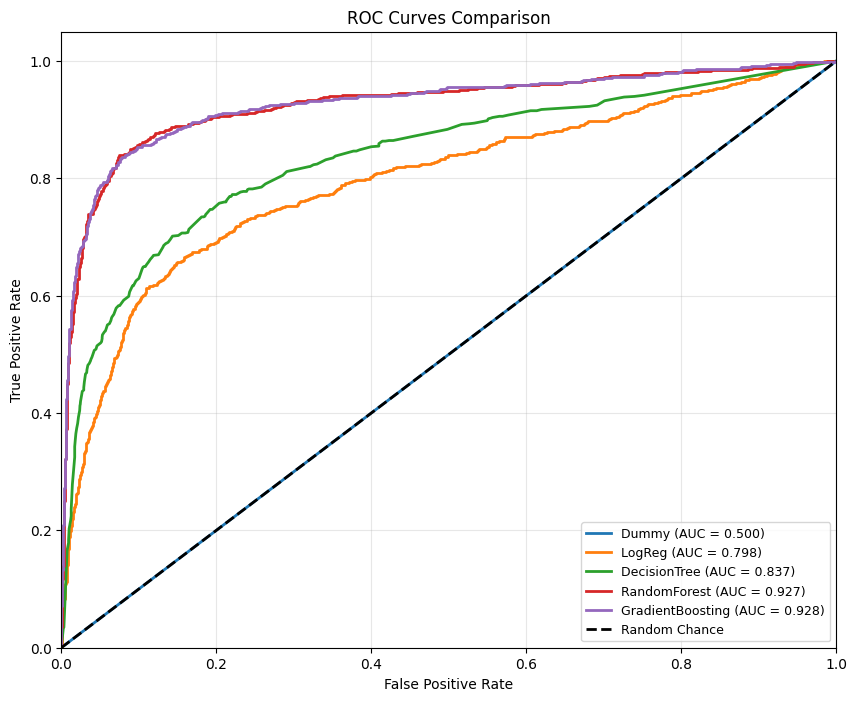

<Figure size 800x600 with 0 Axes>

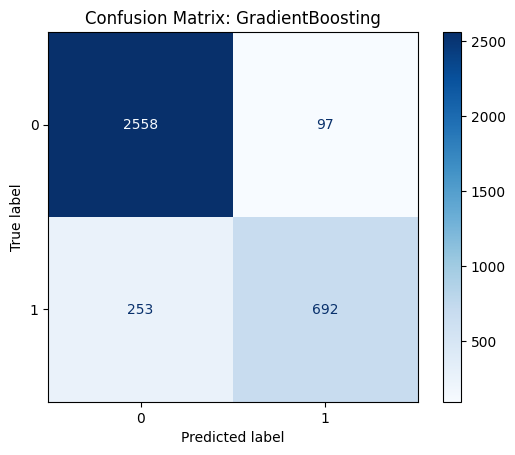

In [12]:
# Создание DataFrame с результатами
results_df = pd.DataFrame(results).T.sort_values(by='ROC-AUC', ascending=False)
print("\nСравнение моделей по метрикам:")
display(results_df)

# Выбор лучшей модели по ROC-AUC
best_model_name = results_df.index[0]
print(f"\nЛучшая модель по ROC-AUC: {best_model_name}")

# Определение лучшей модели для сохранения
if best_model_name == 'Dummy':
    best_model = dummy_clf
elif best_model_name == 'LogReg':
    best_model = logreg_pipe
elif best_model_name == 'DecisionTree':
    best_model = dt_grid.best_estimator_
elif best_model_name == 'RandomForest':
    best_model = rf_grid.best_estimator_
elif best_model_name == 'GradientBoosting':
    best_model = gb_grid.best_estimator_
else:
    best_model = logreg_pipe  # fallback

# ROC-кривые для всех моделей
plt.figure(figsize=(10, 8))

models_map = {
    'Dummy': dummy_clf,
    'LogReg': logreg_pipe,
    'DecisionTree': dt_grid.best_estimator_,
    'RandomForest': rf_grid.best_estimator_,
    'GradientBoosting': gb_grid.best_estimator_,
}

for name, model in models_map.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.savefig(FIGURES_DIR / 'roc_curves_comparison.png', bbox_inches='tight')
plt.show()

# Confusion Matrix для лучшей модели
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, best_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.savefig(FIGURES_DIR / 'confusion_matrix_best.png', bbox_inches='tight')
plt.show()


Вычисление permutation importance для GradientBoosting...


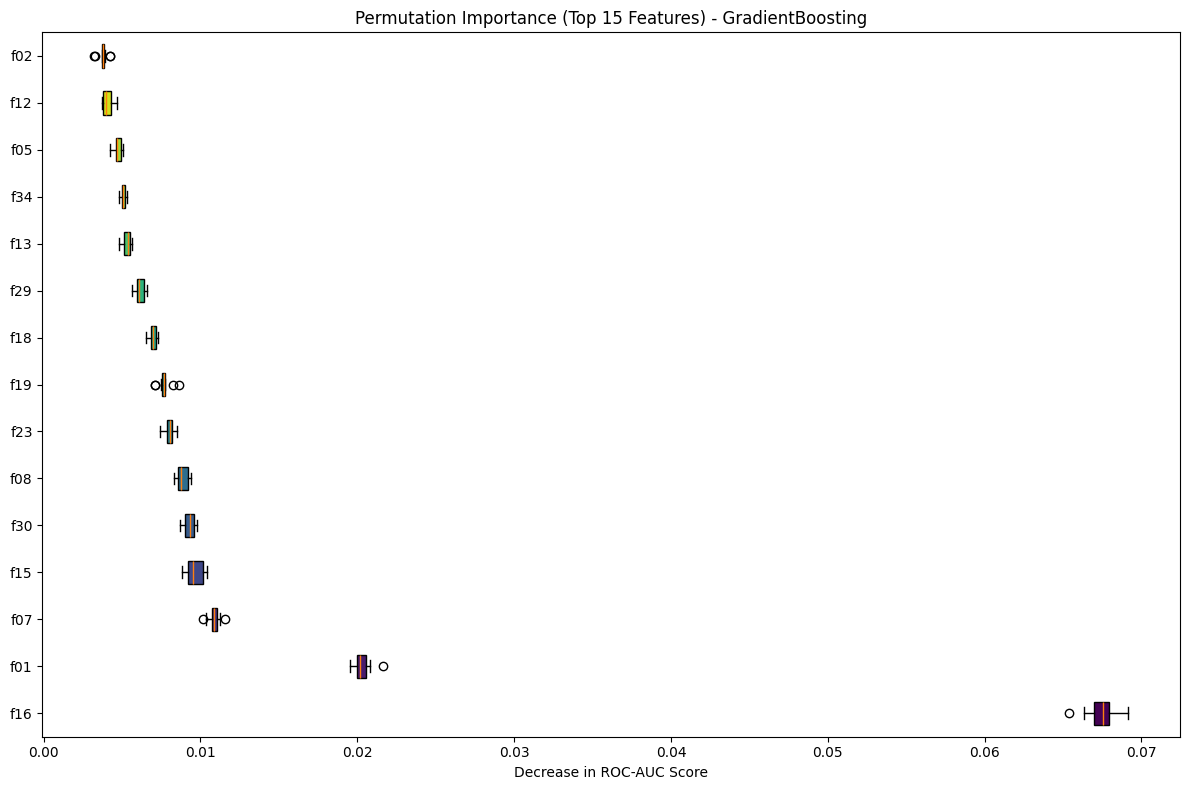


Топ-10 важнейших признаков:
1. f16: 0.0675 ± 0.0011
2. f01: 0.0203 ± 0.0006
3. f07: 0.0108 ± 0.0004
4. f15: 0.0096 ± 0.0005
5. f30: 0.0093 ± 0.0004
6. f08: 0.0089 ± 0.0003
7. f23: 0.0080 ± 0.0003
8. f19: 0.0077 ± 0.0004
9. f18: 0.0070 ± 0.0003
10. f29: 0.0061 ± 0.0003


In [14]:
# Permutation Importance для лучшей модели
print(f"\nВычисление permutation importance для {best_model_name}...")

# Используем train данные для интерпретации (чтобы не "загрязнять" тест)
perm_importance = permutation_importance(
    best_model, X_train, y_train, 
    n_repeats=10, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    scoring='roc_auc'
)

# Сортировка признаков по важности
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
top_n = 15
top_features = X.columns[sorted_idx[:top_n]].tolist()


plt.figure(figsize=(12, 8))
bp = plt.boxplot(
    perm_importance.importances[sorted_idx[:top_n]].T,
    vert=False,
    tick_labels=X.columns[sorted_idx[:top_n]],  # ИСПРАВЛЕНО: tick_labels вместо labels
    patch_artist=True
)

# Настройка цветов
colors = plt.cm.viridis(np.linspace(0, 1, top_n))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.xlabel('Decrease in ROC-AUC Score')
plt.title(f'Permutation Importance (Top {top_n} Features) - {best_model_name}')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance.png', bbox_inches='tight')
plt.show()

# Вывод важнейших признаков
print("\nТоп-10 важнейших признаков:")
for i, idx in enumerate(sorted_idx[:10]):
    feature = X.columns[idx]
    mean_importance = perm_importance.importances_mean[idx]
    std_importance = perm_importance.importances_std[idx]
    print(f"{i+1}. {feature}: {mean_importance:.4f} ± {std_importance:.4f}")

# Интерпретация: 
# Permutation importance показывает, насколько ухудшается качество модели (ROC-AUC) при случайном перемешивании значений признака.
# Более высокое значение означает большую важность признака для предсказаний модели.
# Это надежный метод оценки важности признаков, так как он измеряет фактическое влияние признаков на производительность модели.


In [15]:
# Сохранение метрик в JSON
results_df.to_json(ARTIFACTS_DIR / 'metrics_test.json', orient='index', indent=4)
print(f"\nМетрики сохранены в: {ARTIFACTS_DIR / 'metrics_test.json'}")

# Сохранение результатов поиска гиперпараметров
with open(ARTIFACTS_DIR / 'search_summaries.json', 'w') as f:
    json.dump(search_summaries, f, indent=4, default=str)
print(f"Результаты поиска гиперпараметров сохранены в: {ARTIFACTS_DIR / 'search_summaries.json'}")

# Сохранение лучшей модели
joblib.dump(best_model, ARTIFACTS_DIR / 'best_model.joblib')
print(f"Лучшая модель сохранена в: {ARTIFACTS_DIR / 'best_model.joblib'}")

# Сохранение метаданных
meta = {
    "best_model_name": best_model_name,
    "dataset": DATASET_PATH,
    "metrics": results[best_model_name],
    "random_state": RANDOM_STATE,
    "feature_importance_top10": {feature: float(perm_importance.importances_mean[idx]) 
                               for idx, feature in zip(sorted_idx[:10], X.columns[sorted_idx[:10]])},
    "model_params": str(best_model.get_params()) if hasattr(best_model, 'get_params') else "Pipeline model"
}
with open(ARTIFACTS_DIR / 'best_model_meta.json', 'w') as f:
    json.dump(meta, f, indent=4)
print(f"Метаданные сохранены в: {ARTIFACTS_DIR / 'best_model_meta.json'}")

# Итоговое сообщение
print("\n" + "="*50)
print("Эксперимент завершен успешно!")
print(f"Лучшая модель: {best_model_name}")
print(f"ROC-AUC на тесте: {results[best_model_name]['ROC-AUC']:.4f}")
print(f"Все артефакты сохранены в: {ARTIFACTS_DIR}")
print("="*50)


Метрики сохранены в: artifacts\metrics_test.json
Результаты поиска гиперпараметров сохранены в: artifacts\search_summaries.json
Лучшая модель сохранена в: artifacts\best_model.joblib
Метаданные сохранены в: artifacts\best_model_meta.json

Эксперимент завершен успешно!
Лучшая модель: GradientBoosting
ROC-AUC на тесте: 0.9280
Все артефакты сохранены в: artifacts
